In [1]:
import networkx as nx
import igraph as ig
import pandas as pd

from glob import glob
from natsort import natsorted

import matplotlib.pyplot as plt
import pickle

In [ ]:
turkey_election_networks_dir = "/chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/USER_TAG_cooccurrence/*.pkl"
usc_truthsocial_networks_dir = "/chistera/CaseStudyOutputs/usc_truthsocial_enrichments/temporal_networks/USER_TAG_cooccurrence/*.pkl"
usc_twitter_networks_dir = "/chistera/CaseStudyOutputs/usc_twitter_enrichments/temporal_networks/USER_TAG_cooccurrence/*.pkl"

dataset2window_networks_MQ_scores = {
    "usc_twitter":[],
    "usc_truthsocial":[],
    "turkey_election":[]
}

for path_template in [turkey_election_networks_dir, 
                      usc_truthsocial_networks_dir, 
                      usc_twitter_networks_dir]:
    for fpath in natsorted(glob(path_template)):
        with open(fpath, "rb") as f:
            network_result = pickle.load(f)
            edges_df = network_result['network'].edges
            edge_count = len(edges_df)
            tuples = edges_df[['src', 'dst', 'weight']].itertuples(index=False, name=None)
            g = ig.Graph.TupleList(tuples, directed=False, weights=True, vertex_name_attr="name")
            communities = g.community_multilevel(weights=g.es['weight'])
            modularity_score = g.modularity(communities)
            n_communities = len(communities)

            modularity_score = g.modularity(communities, weights=g.es['weight'])
            print(f"Edge count: {edge_count}")
            print(modularity_score)
            print(n_communities)
            if edge_count == 0:

                print(modularity_score)
                print("HOW COME?")

            network_result["network"].meta.update({
                "modularity_score": modularity_score,
                "n_communities": n_communities
            })

            date = network_result['window_start']
            if "turkish_election2023" in fpath:
                dataset = "turkey_election"
            elif "truthsocial" in fpath:
                dataset = "usc_truthsocial"
            else:
                dataset = "usc_twitter"
            dataset2window_networks_MQ_scores[dataset].append((date, modularity_score, edge_count, n_communities))

        with open(fpath, "wb") as f:
            pickle.dump(network_result, f)
        print(f"Updated and saved: {fpath}")
        print("***")


Edge count: 277721
0.4008826166993383
145
Updated and saved: /chistera/CaseStudyOutputs/temporal_networks/USER_TAG_cooccurrence/USER_TAG_cooccurrence_20230101_20230108.pkl
***
Edge count: 381740
0.380314149558445
156
Updated and saved: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/USER_TAG_cooccurrence/USER_TAG_cooccurrence_20230108_20230115.pkl
***
Edge count: 389073
0.35859004457791
132
Updated and saved: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/USER_TAG_cooccurrence/USER_TAG_cooccurrence_20230115_20230122.pkl
***
Edge count: 399831
0.35667826620783616
159
Updated and saved: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/USER_TAG_cooccurrence/USER_TAG_cooccurrence_20230122_20230129.pkl
***
Edge count: 396794
0.3384987562441666
154
Updated and saved: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/USER_TAG_cooccurrence/USER_TAG_cooccurrence_20230129_2023020

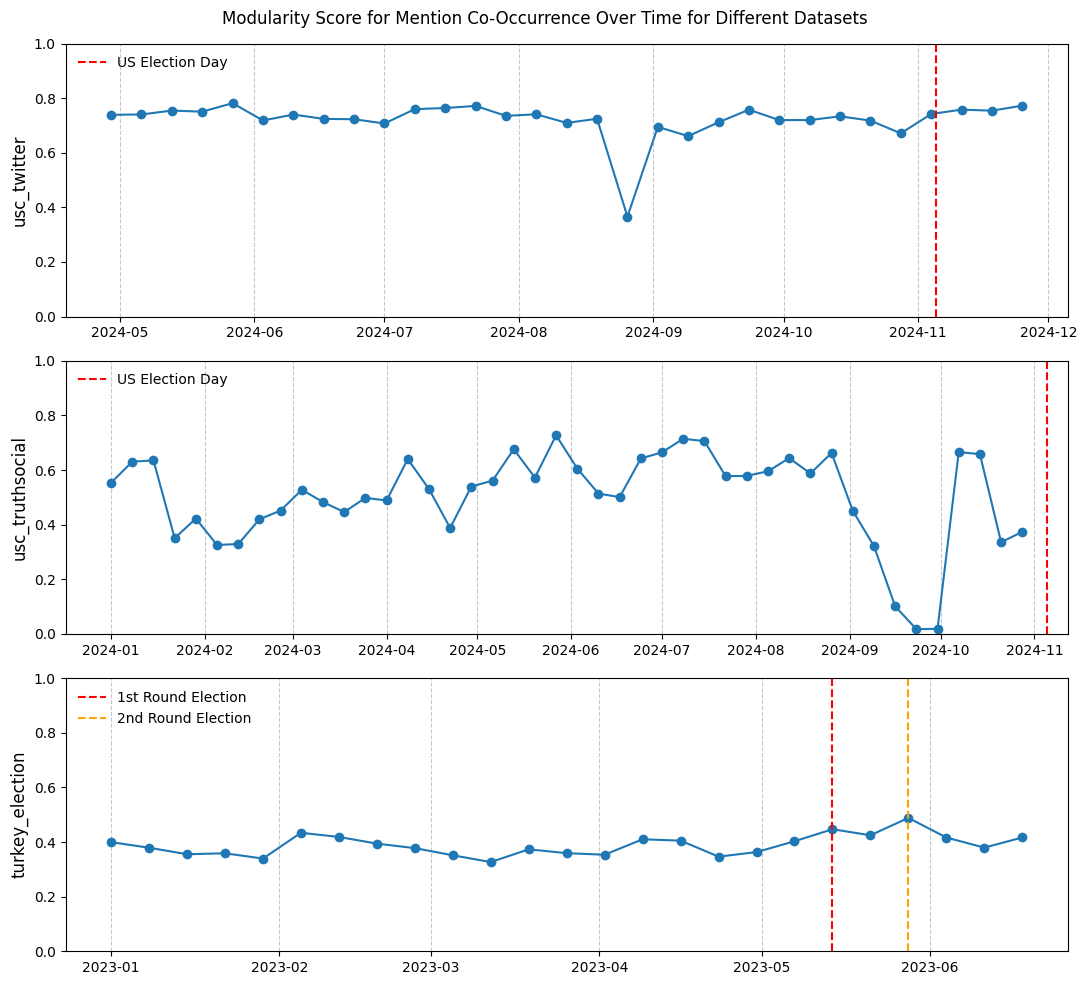

In [ ]:
TURKEY_ELECTION_DATE_FIRST_ROUOND = "2023-05-14"
TURKEY_ELECTION_DATE_SECOND_ROUOND = "2023-05-28"

US_ELECTION_DATE = "2024-11-05"


fig, axs = plt.subplots(3, 1, figsize=(11, 10))
for ax, (dataset, scores) in zip(axs, dataset2window_networks_MQ_scores.items()):
    dates, modularity_scores, edge_count, n_communities = zip(*scores)
    ax.plot(dates, modularity_scores, marker='o')
    # ax.set_title(f'Modularity Score Over Time - {dataset}')
    ax.set_ylabel(f'{dataset}', fontsize=12)

    # enable vertical grid lines
    ax.grid(axis='x', linestyle='--', alpha=0.7)


    for tick in ax.get_xticklabels():
        # tick.set_rotation(15)
        tick.set_fontsize(10)

    ax.set_ylim(0, 1)

    if dataset == "turkey_election":
        ax.axvline(pd.to_datetime(TURKEY_ELECTION_DATE_FIRST_ROUOND), color='red', linestyle='--', label='1st Round Election')
        ax.axvline(pd.to_datetime(TURKEY_ELECTION_DATE_SECOND_ROUOND), color='orange', linestyle='--', label='2nd Round Election')
    elif dataset in ["usc_truthsocial", "usc_twitter"]:
        ax.axvline(pd.to_datetime(US_ELECTION_DATE), color='red', linestyle='--', label='US Election Day')
        # add to the legend
    ax.legend(frameon=False, fontsize=10)


    # twin_ax = ax.twinx()
    # twin_ax.plot(dates, edge_count, color='green', marker='x', alpha=0.5)
fig.suptitle('Modularity Score for Mention Co-Occurrence Over Time for Different Datasets', fontsize=12)
fig.tight_layout()

[usc_twitter] Edge counts:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 83494, 209566, 45231, 70505, 70786, 46935, 361615, 288975, 57552, 287425, 481740, 491642, 185176, 5649, 271745, 408402, 196235, 1919, 48534, 64698, 372353, 335910, 265627, 266865, 178189, 108254, 81764, 58865, 171596, 420680, 324054, 0, 0, 0, 0, 0]
------------------------------
[usc_truthsocial] Edge counts:
[1017, 1542, 2521, 4556, 5067, 5948, 6207, 5629, 5575, 4825, 5733, 3444, 2664, 2930, 4585, 2367, 2622, 2342, 4271, 3698, 4537, 6216, 4438, 7216, 9174, 10174, 8304, 14082, 17119, 11897, 10619, 9164, 10110, 8517, 6857, 428, 279, 7, 13, 228, 1503, 4842, 2146, 1010, 0, 0, 0, 0, 0, 0, 0, 0, 0]
------------------------------
[turkey_election] Edge counts:
[277721, 381740, 389073, 399831, 396794, 296495, 169928, 200818, 331284, 382425, 584573, 948730, 580497, 469064, 374836, 292664, 341714, 320445, 312268, 309245, 301434, 198043, 136584, 154399, 125042, 0]
------------------------------


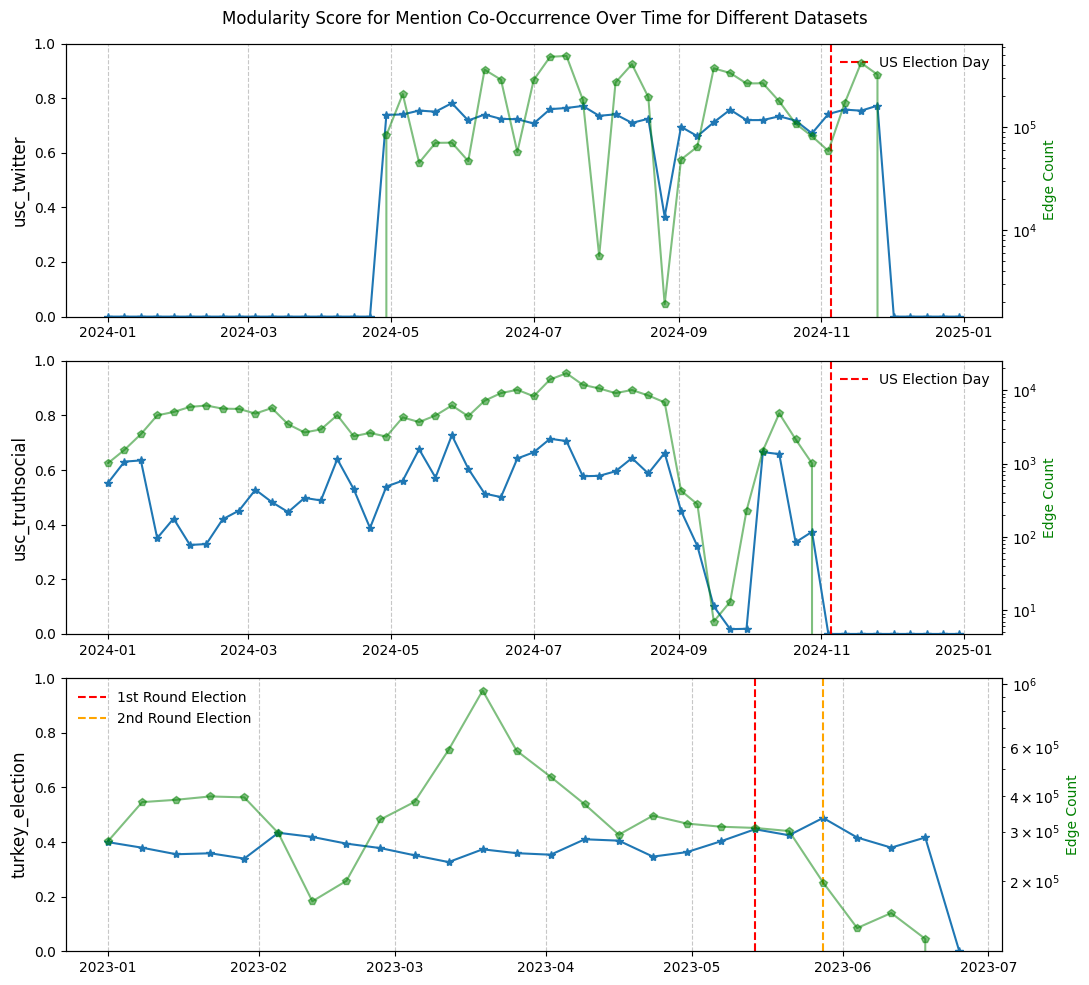

In [ ]:
TURKEY_ELECTION_DATE_FIRST_ROUOND = "2023-05-14"
TURKEY_ELECTION_DATE_SECOND_ROUOND = "2023-05-28"

US_ELECTION_DATE = "2024-11-05"


fig, axs = plt.subplots(3, 1, figsize=(11, 10))
for ax, (dataset, scores) in zip(axs, dataset2window_networks_MQ_scores.items()):
    dates, modularity_scores, edge_count, n_communities = zip(*scores)
    # fill the nan values with 0
    modularity_scores = [0 if pd.isna(v) else v for v in modularity_scores]
    edge_count = [0 if pd.isna(v) else v for v in edge_count]
    dates = pd.to_datetime(dates)
    ax.plot(dates, modularity_scores, marker='*')
    # ax.set_title(f'Modularity Score Over Time - {dataset}')
    ax.set_ylabel(f'{dataset}', fontsize=12)

    # enable vertical grid lines
    ax.grid(axis='x', linestyle='--', alpha=0.7)


    for tick in ax.get_xticklabels():
        # tick.set_rotation(15)
        tick.set_fontsize(10)

    ax.set_ylim(0, 1)

    if dataset == "turkey_election":
        ax.axvline(pd.to_datetime(TURKEY_ELECTION_DATE_FIRST_ROUOND), color='red', linestyle='--', label='1st Round Election')
        ax.axvline(pd.to_datetime(TURKEY_ELECTION_DATE_SECOND_ROUOND), color='orange', linestyle='--', label='2nd Round Election')
    elif dataset in ["usc_truthsocial", "usc_twitter"]:
        ax.axvline(pd.to_datetime(US_ELECTION_DATE), color='red', linestyle='--', label='US Election Day')
        # add to the legend
    ax.legend(frameon=False, fontsize=10)


    twin_ax = ax.twinx()
    twin_ax.plot(dates, edge_count, color='green', marker='p', alpha=0.5)
    twin_ax.set_ylabel('Edge Count', color='green', fontsize=10)
    twin_ax.set_yscale('log')
    
    print(f"[{dataset}] Edge counts:")
    print(edge_count)
    print("------------------------------")
fig.suptitle('Modularity Score for Mention Co-Occurrence Over Time for Different Datasets', fontsize=12)
fig.tight_layout()

# Hashtag Coocurrence Networks

In [2]:
import igraph as ig
from natsort import natsorted
from glob import glob
import pickle


turkey_election_networks_dir = "/chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/*.pkl"
usc_truthsocial_networks_dir = "/chistera/CaseStudyOutputs/usc_truthsocial_enrichments/temporal_networks/HASHTAG_cooccurrence/*.pkl"
usc_twitter_networks_dir = "/chistera/CaseStudyOutputs/usc_twitter_enrichments/temporal_networks/HASHTAG_cooccurrence/*.pkl"

dataset2window_networks_GCC_scores = {
    "usc_twitter":[],
    "usc_truthsocial":[],
    "turkey_election":[]
}

for path_template in [turkey_election_networks_dir, 
                      usc_truthsocial_networks_dir, 
                      usc_twitter_networks_dir]:
    
    for fpath in natsorted(glob(path_template)):
        with open(fpath, "rb") as f:
            network_result = pickle.load(f)
            edges_df = network_result['network'].edges
            edge_count = len(edges_df)

            # Create graph
            tuples = edges_df[['src', 'dst', 'weight']].itertuples(index=False, name=None)
            g = ig.Graph.TupleList(tuples, directed=False, weights=True, vertex_name_attr="name")
            
            # Detect communities
            communities = g.community_multilevel(weights=g.es['weight'])

            community_clustering_coeffs = []

            for i, nodes in enumerate(communities):
                # Induce a subgraph for the current community
                subgraph = g.subgraph(nodes)
                
                # Calculate Global Clustering Coefficient (Transitivity)
                # 'undirected' mode is appropriate for co-occurrence networks
                cc = subgraph.transitivity_undirected()
                
                community_clustering_coeffs.append({
                    "community_id": i,
                    "n_nodes": subgraph.vcount(),
                    "clustering_coefficient": cc
                })

            # Identify dataset for storage
            if "turkish_election2023" in fpath:
                dataset = "turkey_election"
            elif "truthsocial" in fpath:
                dataset = "usc_truthsocial"
            else:
                dataset = "usc_twitter"

            date = network_result['window_start']
            
            # Store the list of coefficients in your results dictionary
            dataset2window_networks_GCC_scores[dataset].append({
                "date": date,
                "edge_count": edge_count,
                "n_communities": len(communities),
                "community_scores": community_clustering_coeffs
            })

        print(f"Processed: {fpath} | Communities found: {len(communities)}")
        print("***")

Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/HASHTAG_cooccurrence_20230101_20230108.pkl | Communities found: 126
***
Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/HASHTAG_cooccurrence_20230108_20230115.pkl | Communities found: 131
***
Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/HASHTAG_cooccurrence_20230115_20230122.pkl | Communities found: 148
***
Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/HASHTAG_cooccurrence_20230122_20230129.pkl | Communities found: 157
***
Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/HASHTAG_cooccurrence_20230129_20230205.pkl | Communities found: 128
***
Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/H

In [3]:
import pandas as pd


dataset2flatten_community_GCC_scores = {
    "usc_twitter":[],
    "usc_truthsocial":[],
    "turkey_election":[]
}
for dataset_name in ["usc_twitter", "usc_truthsocial", "turkey_election"]:
    for window in dataset2window_networks_GCC_scores[dataset_name]:
        for community in window["community_scores"]:
            if not pd.isna(community["clustering_coefficient"]):
                dataset2flatten_community_GCC_scores[dataset_name].append(community["clustering_coefficient"])

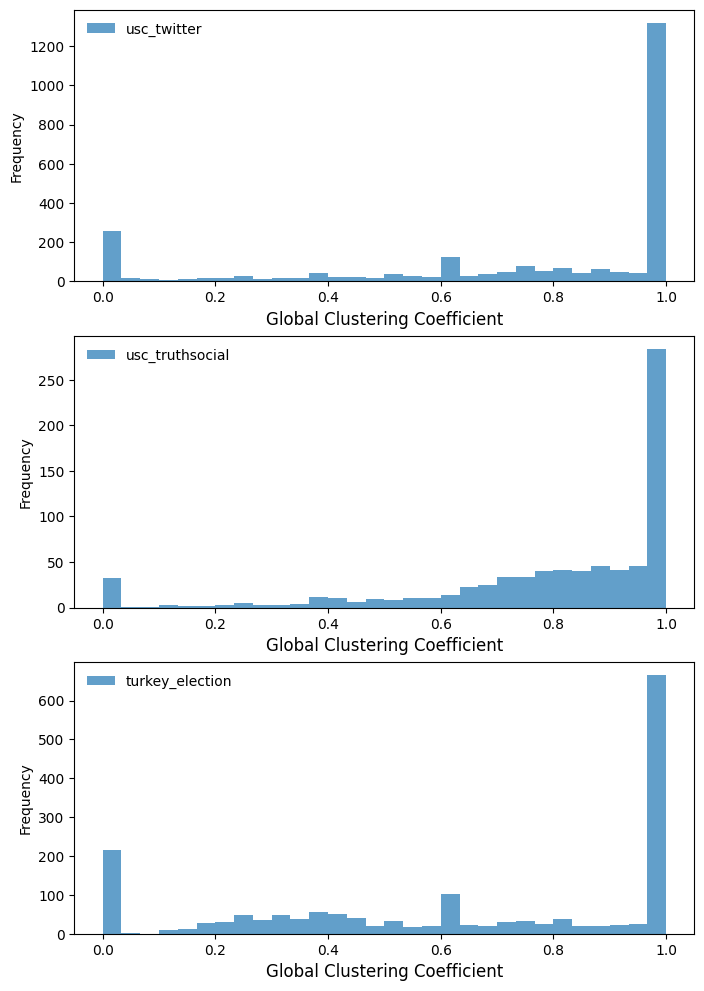

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(8, 12))

for ax, (dataset, scores) in zip(axs, dataset2flatten_community_GCC_scores.items()):
    ax.hist(scores, bins=30, alpha=0.7, label=dataset)
    # ax.set_title(f'Community Global Clustering Coefficient Distribution - {dataset}')
    # ax.set_xlabel('Global Clustering Coefficient')

    ax.set_xlabel('Global Clustering Coefficient', fontsize=12)
    ax.legend(frameon=False)
    ax.set_ylabel('Frequency')


In [1]:

import igraph as ig
from natsort import natsorted
from glob import glob
import pickle
import pandas as pd
from collections import defaultdict


turkey_election_networks_dir = "/chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/*.pkl"
usc_truthsocial_networks_dir = "/chistera/CaseStudyOutputs/usc_truthsocial_enrichments/temporal_networks/HASHTAG_cooccurrence/*.pkl"
usc_twitter_networks_dir = "/chistera/CaseStudyOutputs/usc_twitter_enrichments/temporal_networks/HASHTAG_cooccurrence/*.pkl"
finland_twitter_network_dir = "/chistera/CaseStudyOutputs/finnish_db_enrichments/temporal_networks/HASHTAG_cooccurrence/*.pkl"

# We store (degree, clustering) pairs for every node in every snapshot
node_stats_data = defaultdict(list)

for path_template in [turkey_election_networks_dir, 
                      usc_truthsocial_networks_dir, 
                      usc_twitter_networks_dir,
                      finland_twitter_network_dir]:
    
    for fpath in natsorted(glob(path_template)):
        with open(fpath, "rb") as f:
            network_result = pickle.load(f)
            
            # 1. Load the graph
            # Assuming 'network' is a dataframe or igraph object. 
            # If it's a pandas DF, convert to igraph:
            edges_df = network_result['network'].edges


            # itertuples(index=False) provides (source, target, weight)
            tuples = list(edges_df.itertuples(index=False))


            # Use vertex_name_attr to tell igraph the first two elements are names
            # If your edges_df has exactly 3 columns, igraph usually assigns the 3rd as 'weight' automatically
            g = ig.Graph.TupleList(tuples, directed=False, vertex_name_attr="name", edge_attrs="weight")
            node_names = g.vs["name"]
            # 2. Calculate Node-Level Metrics
            # Local Clustering Coefficient (Transitivity in igraph)
            local_clustering = g.transitivity_local_undirected()
            # Node Degrees
            degrees = g.degree()
            
            # 3. Identify dataset
            if "turkish_election2023" in fpath:
                dataset = "turkey_election"
            elif "truthsocial" in fpath:
                dataset = "usc_truthsocial"
            elif "finnish_db" in fpath:
                dataset = "finland_twitter"
            else:
                dataset = "usc_twitter"

            # 4. Store (di, Ci) pairs for the Heatmap
            # We filter out nodes with degree < 2 because clustering is undefined/zero
            for i in range(g.vcount()):
                d = degrees[i]
                c = local_clustering[i]
                
                if d > 1:
                    # No need to use .find(); just use the index 'i'
                    node_stats_data[dataset].append({
                        "degree": d,
                        "clustering": c,
                        "node_label": node_names[i]
                    })
        print(f"Processed: {fpath} | Nodes: {g.vcount()} | Edges: {g.ecount()}")
        print("***")

Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/HASHTAG_cooccurrence_20230101_20230108.pkl | Nodes: 3332 | Edges: 22312
***
Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/HASHTAG_cooccurrence_20230108_20230115.pkl | Nodes: 4164 | Edges: 29978
***
Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/HASHTAG_cooccurrence_20230115_20230122.pkl | Nodes: 3928 | Edges: 26719
***
Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/HASHTAG_cooccurrence_20230122_20230129.pkl | Nodes: 4224 | Edges: 29303
***
Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/HASHTAG_cooccurrence/HASHTAG_cooccurrence_20230129_20230205.pkl | Nodes: 4206 | Edges: 30188
***
Processed: /chistera/CaseStudyOutputs/turkish_election2023_enrichments

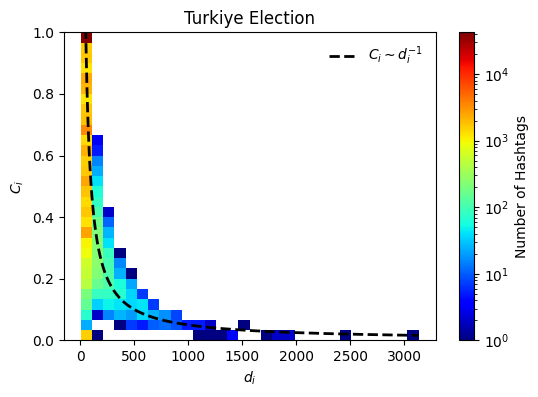

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
df_plot = pd.DataFrame(node_stats_data["turkey_election"])

# Filter out degrees < 2 if you haven't already, as Ci is undefined/zero
df_filtered_turkey = df_plot[df_plot['degree'] > 1]

plt.figure(figsize=(6, 4))

# We use histplot directly on the DataFrame. 
# Increasing bins to 30 or 50 helps reveal the 1/d relationship.
sns.histplot(
    data=df_filtered_turkey, 
    x="degree", 
    y="clustering", 
    bins=30,               # Seaborn will handle the (log, linear) binning
    pthresh=None,          # Shows all bins even with low counts
    cmap=cm.jet, 
    cbar=True,
    cbar_kws={'label': 'Number of Hashtags'},
    # log_scale=(True, False) 
    norm=LogNorm(),
    vmin=None, 
    vmax=None,

)

# Optional: Add the theoretical line Ci = 1/di to see the fit
import numpy as np
d_range = np.arange(df_filtered_turkey['degree'].min(), df_filtered_turkey['degree'].max())
plt.plot(d_range, 50/d_range, color='black', linestyle='--', alpha=1,linewidth=2 , label='$C_i \sim d_i^{-1}$')

plt.title("Turkiye Election")
plt.xlabel("$d_i$")
plt.ylabel("$C_i$")
# plt.xlim(0, 500)
plt.ylim(0, 1)
plt.legend(frameon=False)
plt.savefig("turkey_election_degree_clustering_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
temp_df = df_filtered_turkey.sort_values(by="clustering", ascending=False)
temp_df = temp_df[temp_df["degree"] < 3]
temp_df.iloc[:10]

,degree,clustering,node_label
34,2,1.0,emeklikorucu
86093,2,1.0,yavuza
61855,2,1.0,hadi
61868,2,1.0,herkesekadrovaruzm
86024,2,1.0,11402lira
86025,2,1.0,zorunluemekliadaletbekliyor
85995,2,1.0,kurd
85996,2,1.0,kurdistan
85997,2,1.0,iyiak
86001,2,1.0,azerbaycan


In [ ]:
temp_df = df_filtered_turkey.sort_values(by="clustering", ascending=True)
temp_df = temp_df[temp_df["degree"] > 1000]
temp_df.iloc[:100]

,degree,clustering,node_label
70145,3133,0.010806,secim2023
50367,1897,0.013337,secim2023
65358,2436,0.015110,secim2023
15903,1943,0.016209,deprem
57192,1766,0.017224,secim2023
61181,1875,0.017768,secim2023
75242,1856,0.021236,secim2023
19223,1363,0.023202,deprem
42804,1375,0.023272,secim2023
53963,1240,0.023278,secim2023


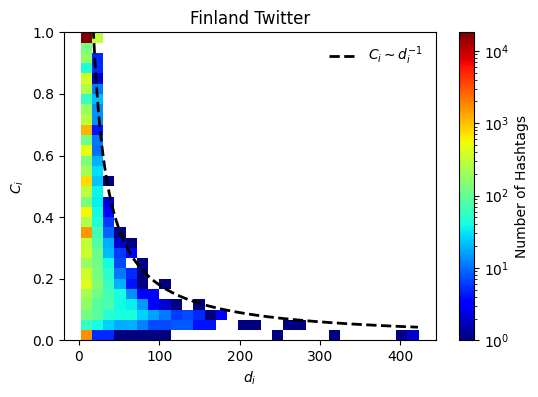

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
df_plot = pd.DataFrame(node_stats_data["finland_twitter"])

# Filter out degrees < 2 if you haven't already, as Ci is undefined/zero
df_filtered_finland = df_plot[df_plot['degree'] > 1]

plt.figure(figsize=(6, 4))

# We use histplot directly on the DataFrame. 
# Increasing bins to 30 or 50 helps reveal the 1/d relationship.
sns.histplot(
    data=df_filtered_finland, 
    x="degree", 
    y="clustering", 
    bins=30,               # Seaborn will handle the (log, linear) binning
    pthresh=None,          # Shows all bins even with low counts
    cmap=cm.jet, 
    cbar=True,
    cbar_kws={'label': 'Number of Hashtags'},
    # log_scale=(True, False) 
    norm=LogNorm(),
    vmin=None, 
    vmax=None,

)

# Optional: Add the theoretical line Ci = 1/di to see the fit
import numpy as np
d_range = np.arange(df_filtered_finland['degree'].min(), df_filtered_finland['degree'].max())
plt.plot(d_range, 18/d_range, color='black', linestyle='--', alpha=1,linewidth=2 , label='$C_i \sim d_i^{-1}$')

plt.title("Finland Twitter")
plt.xlabel("$d_i$")
plt.ylabel("$C_i$")
# plt.xlim(0, 500)
plt.ylim(0, 1)
plt.legend(frameon=False)
plt.savefig("finland_twitter_degree_clustering_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [14]:
temp_df = df_filtered_finland.sort_values(by="clustering", ascending=False)
temp_df = temp_df[temp_df["degree"] < 3]
temp_df.iloc[:10]

,degree,clustering,node_label
31503,2,1.0,rahaaon
0,2,1.0,kiertotalousosaamista
31502,2,1.0,JariSarasvuo
31500,2,1.0,Oikeisto
31499,2,1.0,Fasismi
31497,2,1.0,StrongerTogether
31496,2,1.0,Linnut
31458,2,1.0,puoluekannatus
31462,2,1.0,女m
31464,2,1.0,CamGirl


In [22]:
temp_df = df_filtered_finland.sort_values(by="clustering", ascending=True)
temp_df = temp_df[temp_df["degree"] > 200]
temp_df.iloc[:100]

,degree,clustering,node_label
29810,419,0.023855,eduskuntavaalit2023
29800,423,0.024167,vaalit2023
28387,405,0.024948,vaalit2023
27046,320,0.026685,eduskuntavaalit2023
25895,247,0.031928,eduskuntavaalit2023
25931,209,0.037127,vaalit2023
27091,259,0.038071,vaalit2023
28384,280,0.040067,eduskuntavaalit2023
28394,221,0.060798,eduskuntavaalit


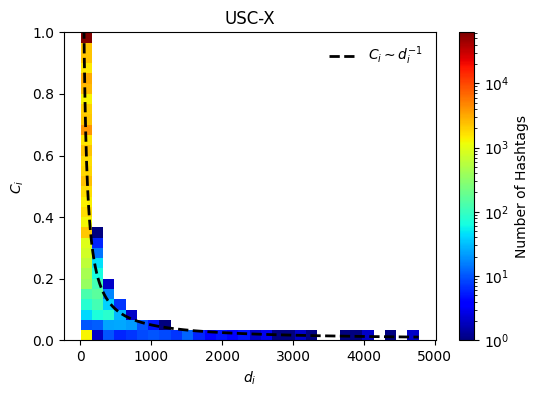

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import LogNorm

df_plot = pd.DataFrame(node_stats_data["usc_twitter"])

# Filter out degrees < 2 if you haven't already, as Ci is undefined/zero
df_filtered_usc_twitter = df_plot[df_plot['degree'] > 1]

plt.figure(figsize=(6, 4))

# We use histplot directly on the DataFrame. 
# Increasing bins to 30 or 50 helps reveal the 1/d relationship.
sns.histplot(
    data=df_filtered_usc_twitter, 
    x="degree", 
    y="clustering", 
    bins=30,               # Seaborn will handle the (log, linear) binning
    pthresh=None,          # Shows all bins even with low counts
    cmap=cm.jet, 
    cbar=True,
    cbar_kws={'label': 'Number of Hashtags' },
    # log_scale=(True, False) 
    norm=LogNorm(),
    vmin=None, 
    vmax=None,

)

 
d_range = np.arange(df_filtered_usc_twitter['degree'].min(), df_filtered_usc_twitter['degree'].max())
plt.plot(d_range, 50/d_range, color='black', linestyle='--', alpha=1,linewidth=2 , label='$C_i \sim d_i^{-1}$')

plt.title("USC-X")
plt.xlabel("$d_i$")
plt.ylabel("$C_i$")
# plt.xlim(0, 500)
plt.ylim(0, 1)
plt.legend(frameon=False)
plt.savefig("usc_twitter_degree_clustering_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [24]:
temp_df = df_filtered_usc_twitter.sort_values(by="clustering", ascending=False)
temp_df = temp_df[temp_df["degree"] < 3]
temp_df.iloc[:10]

,degree,clustering,node_label
11,2,1.0,uspolitics
107335,2,1.0,ninaturner2028
107334,2,1.0,lyingdems
107332,2,1.0,savingamerica
107294,2,1.0,voting
107295,2,1.0,skybastards
107296,2,1.0,5gw
107297,2,1.0,pierrepoilievre4pm
107299,2,1.0,laratrump
107300,2,1.0,puppet


In [47]:
temp_df = df_filtered_usc_twitter.sort_values(by="clustering", ascending=True)
temp_df = temp_df[temp_df["degree"] > 2000]
temp_df.iloc[:1000]

,degree,clustering,node_label
90826,3224,0.003055,trump2024
25547,4775,0.004652,biden
35460,4751,0.005111,trump
96853,3083,0.005393,maga
25589,4405,0.005557,trump
35439,4080,0.005869,trump2024
35449,4085,0.006157,biden
35445,3939,0.006423,maga
25564,3671,0.006468,trump2024
53156,3079,0.006502,trump2024


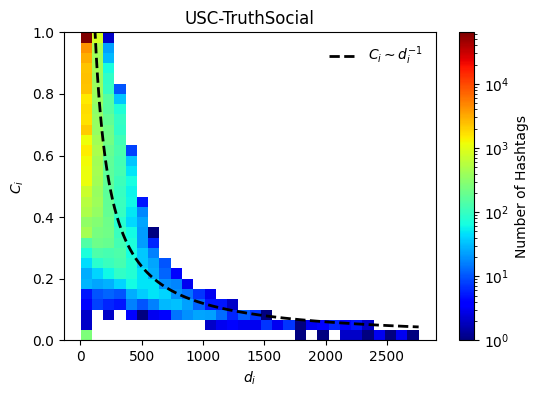

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import LogNorm

df_plot = pd.DataFrame(node_stats_data["usc_truthsocial"])

# Filter out degrees < 2 if you haven't already, as Ci is undefined/zero
df_filtered_usc_truthsocial = df_plot[df_plot['degree'] > 1]

plt.figure(figsize=(6, 4))

# We use histplot directly on the DataFrame. 
# Increasing bins to 30 or 50 helps reveal the 1/d relationship.
sns.histplot(
    data=df_filtered_usc_truthsocial, 
    x="degree", 
    y="clustering", 
    bins=30,               # Seaborn will handle the (log, linear) binning
    pthresh=None,          # Shows all bins even with low counts
    cmap=cm.jet, 
    cbar=True,
    cbar_kws={'label': 'Number of Hashtags'},
    # log_scale=(True, False) 
    norm=LogNorm(),
    vmin=None, 
    vmax=None,
)


import numpy as np
d_range = np.arange(df_filtered_usc_truthsocial['degree'].min(), df_filtered_usc_truthsocial['degree'].max())
plt.plot(d_range, 120/d_range, color='black', linestyle='--', alpha=1,linewidth=2 ,label='$C_i \sim d_i^{-1}$')

plt.title("USC-TruthSocial")
plt.xlabel("$d_i$")
plt.ylabel("$C_i$")

# plt.xlim(0, 500)
plt.ylim(0, 1)
plt.legend(frameon=False)
plt.savefig("usc_truthsocial_degree_clustering_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [27]:
temp_df = df_filtered_usc_truthsocial.sort_values(by="clustering", ascending=False)
temp_df = temp_df[temp_df["degree"] < 3]
temp_df.iloc[:10]

,degree,clustering,node_label
110234,2,1.0,uniparty
110233,2,1.0,mcdonalds
110229,2,1.0,neverkamala
110227,2,1.0,county
110216,2,1.0,commonsense
110217,2,1.0,tommyrobinson
110221,2,1.0,righttolife
110208,2,1.0,jew
62961,2,1.0,godspeed
62962,2,1.0,godfamilycountry


In [28]:
temp_df = df_filtered_usc_truthsocial.sort_values(by="clustering", ascending=True)
temp_df = temp_df[temp_df["degree"] > 2000]
temp_df.iloc[:100]

,degree,clustering,node_label
60978,2460,0.027022,maga
48466,2202,0.027195,maga
65629,2615,0.027725,maga
80603,2760,0.028351,maga
52556,2125,0.028415,maga
44600,2212,0.029436,maga
61107,2223,0.029534,trump2024
65779,2351,0.030477,trump2024
65637,2407,0.030767,trump
86143,2626,0.030978,maga


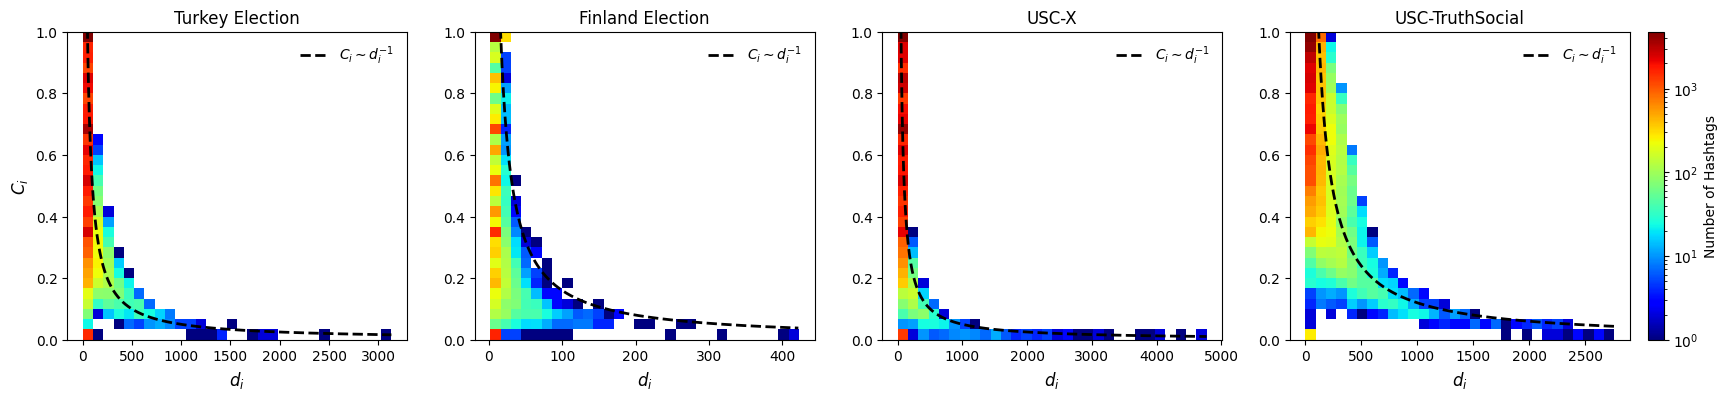

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.cm as cm

fig, axs = plt.subplots(1, 4, figsize=(24, 4))

vmax = max(df_filtered_turkey['degree'].max(), 
           df_filtered_finland['degree'].max(),
           df_filtered_usc_twitter['degree'].max(),
           df_filtered_usc_truthsocial['degree'].max())
shared_norm = LogNorm(vmin=1, vmax=vmax) # Adjust vmax to fit your highest hashtag count

# --- Plot 1: Turkey Election ---
sns.histplot(
    data=df_filtered_turkey, 
    x="degree", 
    y="clustering", 
    bins=30,              
    cmap=cm.jet, 
    cbar=False,           
    ax=axs[0]
)
# Force the LogNorm AFTER the plot is generated to bypass the ValueError
axs[0].collections[0].set_norm(shared_norm)

d_range = np.arange(df_filtered_turkey['degree'].min(), df_filtered_turkey['degree'].max())
axs[0].plot(d_range, 50/d_range, color='black', linestyle='--', alpha=1, linewidth=2, label='$C_i \sim d_i^{-1}$')
axs[0].set_ylim(0, 1)


# --- Plot 2: Finland Election ---
sns.histplot(
    data=df_filtered_finland, 
    x="degree", 
    y="clustering", 
    bins=30,              
    cmap=cm.jet, 
    cbar=False,
    ax=axs[1]
)
axs[1].collections[0].set_norm(shared_norm)

d_range = np.arange(df_filtered_finland['degree'].min(), df_filtered_finland['degree'].max())
axs[1].plot(d_range, 16/d_range, color='black', linestyle='--', alpha=1, linewidth=2, label='$C_i \sim d_i^{-1}$')
axs[1].set_ylim(0, 1)


# --- Plot 3: USC-X ---
sns.histplot(
    data=df_filtered_usc_twitter, 
    x="degree", 
    y="clustering", 
    bins=30,                
    cmap=cm.jet, 
    cbar=False,
    ax=axs[2]
)
axs[2].collections[0].set_norm(shared_norm)

d_range = np.arange(df_filtered_usc_twitter['degree'].min(), df_filtered_usc_twitter['degree'].max())
axs[2].plot(d_range, 50/d_range, color='black', linestyle='--', alpha=1, linewidth=2, label='$C_i \sim d_i^{-1}$')
axs[2].set_ylim(0, 1)


# --- Plot 4: USC-TruthSocial ---
sns.histplot(
    data=df_filtered_usc_truthsocial, 
    x="degree", 
    y="clustering", 
    bins=30,               
    cmap=cm.jet, 
    cbar=False,         
    ax=axs[3]
)
axs[3].collections[0].set_norm(shared_norm)

d_range = np.arange(df_filtered_usc_truthsocial['degree'].min(), df_filtered_usc_truthsocial['degree'].max())
axs[3].plot(d_range, 120/d_range, color='black', linestyle='--', alpha=1, linewidth=2, label='$C_i \sim d_i^{-1}$')
axs[3].set_ylim(0, 1)


# --- Labels and Titles ---
axs[0].set_ylabel("$C_i$", fontsize=12)
axs[0].set_xlabel("$d_i$", fontsize=12)
axs[0].legend(frameon=False)
axs[0].set_title("Turkey Election", fontsize=12)

axs[1].set_ylabel("", fontsize=12)
axs[1].set_xlabel("$d_i$", fontsize=12)
axs[1].legend(frameon=False)
axs[1].set_title("Finland Election", fontsize=12)

axs[2].set_ylabel("", fontsize=12)
axs[2].set_xlabel("$d_i$", fontsize=12)
axs[2].legend(frameon=False)
axs[2].set_title("USC-X", fontsize=12)

axs[3].set_ylabel("", fontsize=12)
axs[3].set_xlabel("$d_i$", fontsize=12)
axs[3].legend(frameon=False)
axs[3].set_title("USC-TruthSocial", fontsize=12)

# --- Add Shared Colorbar ---
# This pulls the color mapping from the first plot and shares it across the figure
fig.colorbar(axs[0].collections[0], ax=axs, label='Number of Hashtags', pad=0.01)

plt.savefig('combined_degree_clustering_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pickle
path = "/chistera/CaseStudyOutputs/turkish_election2023_enrichments/temporal_networks/SHARE_interaction/SHARE_interaction_20230514_20230521.pkl"

with open(path, "rb") as f:
    network_result = pickle.load(f)

In [ ]:
ws = network_result["window_start"]
we = network_result["window_end"]
net = network_result["network"]

print(ws, we, net.meta["edge_count"])

2023-05-14 00:00:00 2023-05-21 00:00:00 562083
